In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
import seaborn as sns

import torch
import torch.nn as nn

reinforce w/ baseline

In [42]:
class ValueFcnApprox(nn.Module):
    def __init__(self, d, d2):
        super().__init__()
        self.fc1 = nn.Linear(d, d2)
        self.sig1 = nn.ReLU()
        self.fc2 = nn.Linear(d2, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.sig1(x)
        x = self.fc2(x)

        return x


class PolicyFcnApprox(nn.Module):
    def __init__(self, d, d2):
        super().__init__()
        self.fc1 = nn.Linear(d, d2)
        self.sig1 = nn.ReLU()
        self.fc2 = nn.Linear(d2, d2)
        self.sig2 = nn.ReLU()
        self.fc3 = nn.Linear(d2, 1)
        self.sig3 = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.sig1(x)
        x = self.fc2(x)
        x = self.sig2(x)
        x = self.fc3(x)
        x = self.sig3(x)

        return x

In [54]:
#init theta in R^d', init w in R^d
INPUT_DIM = 6
LAYER2_DIM = 32
EPISODES = 25000
GAMMA = 1
ALPHA_W = 0.02
ALPHA_THETA = 0.002
BETA = 0.01   # entropy bonus coefficient (raise if the policy still collapses)

def state_to_idx(s): return s[0]-1, s[1]-1, s[2]
def x(s1, s2, s3):
    ps, ds = s1 / 20.0, s2 / 9.0
    return np.array([1.0, ps, ds, float(s3), ps * ds, ps * s3])
def calculate_return(r_ls, GAMMA, t, T):
    out = 0.0
    for k in range(t, T):
        out += GAMMA * r_ls[k]
    return out

env = gym.make("Blackjack-v1", sab=False)


model_v = ValueFcnApprox(INPUT_DIM, LAYER2_DIM)
model_p = PolicyFcnApprox(INPUT_DIM, LAYER2_DIM)
# optimizer_w = torch.optim.SGD(model_v.parameters(), lr=ALPHA_W)
# optimizer_theta = torch.optim.SGD(model_p.parameters(), lr=ALPHA_THETA)
optimizer_w = torch.optim.Adam(model_v.parameters(), lr=1e-3)
optimizer_theta = torch.optim.Adam(model_p.parameters(), lr=3e-4)


wins = []

#for episode in episodes:
for episode in range(EPISODES):
    #generate episode
    s, _ = env.reset()
    x_ls, a_ls, r_ls = [], [], []

    while True:
        s1, s2, s3 = state_to_idx(s)
        xi = torch.tensor(x(s1, s2, s3), dtype=torch.float32)

        p_hit = model_p(xi).squeeze()
        # a = torch.bernoulli(p_hit).long().item()
        # log_pi = torch.log(p_hit if a == 1 else (1 - p_hit))
        dist = torch.distributions.Bernoulli(probs=p_hit)
        a = dist.sample()
        log_pi = dist.log_prob(a)

        x_ls.append(xi)
        a_ls.append(a.item())

        s, r, term, trunc, _ = env.step(int(a.item()))
        r_ls.append(r)

        if term or trunc:
            wins.append(r > 0)
            break
    
    #for t in episode:
    T = len(x_ls)
    for t in range(T):
        #calculate return g, g <- sum from k=t+1 to T gamma^k-1 R_k
        g = calculate_return(r_ls, GAMMA, t, T)
        
        #calculate target minus estimate delta, delta <- g - v(s_t, w)
        v = model_v(x_ls[t]).squeeze()
        delta = g - v
        
        #update weight vector for w, w <- w + alpha * delta del v(s_t, w)
        loss_v = delta**2
        optimizer_w.zero_grad()
        loss_v.backward()
        optimizer_w.step()

        #update policy param theta, theta <- theta + alpha * gamma^t * delta * del ln(pi(a|s, theta))
        p_hit = model_p(x_ls[t]).squeeze()
        dist = torch.distributions.Bernoulli(probs=p_hit)
        log_pi = dist.log_prob(torch.tensor(a_ls[t]))
        entropy = dist.entropy()
        loss_p = -(GAMMA**t) * delta.detach() * log_pi - BETA * entropy
        optimizer_theta.zero_grad()
        loss_p.backward()
        optimizer_theta.step()

In [60]:
ps = [pi_hit(p, d, 0) for p in range(8, 22) for d, _ in dealer_upcards]
print(min(ps), max(ps), np.mean(ps))

0.00014224686310626566 0.007123158313333988 0.0019192085160674261


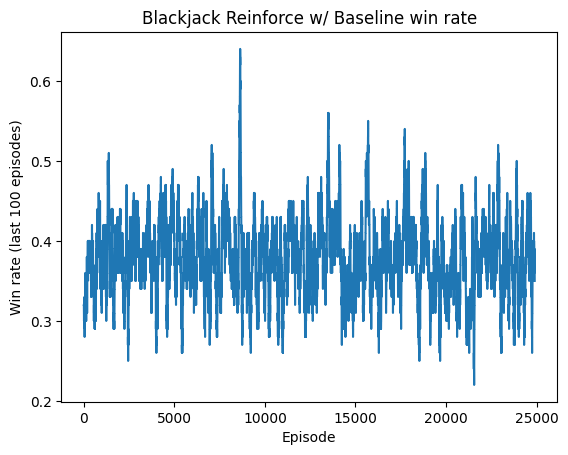

In [61]:
window = 100
win_rate = np.convolve(wins, np.ones(window) / window, mode='valid')

plt.plot(win_rate)
plt.xlabel('Episode')
plt.ylabel(f'Win rate (last {window} episodes)')
plt.title('Blackjack Reinforce w/ Baseline win rate')
plt.show()

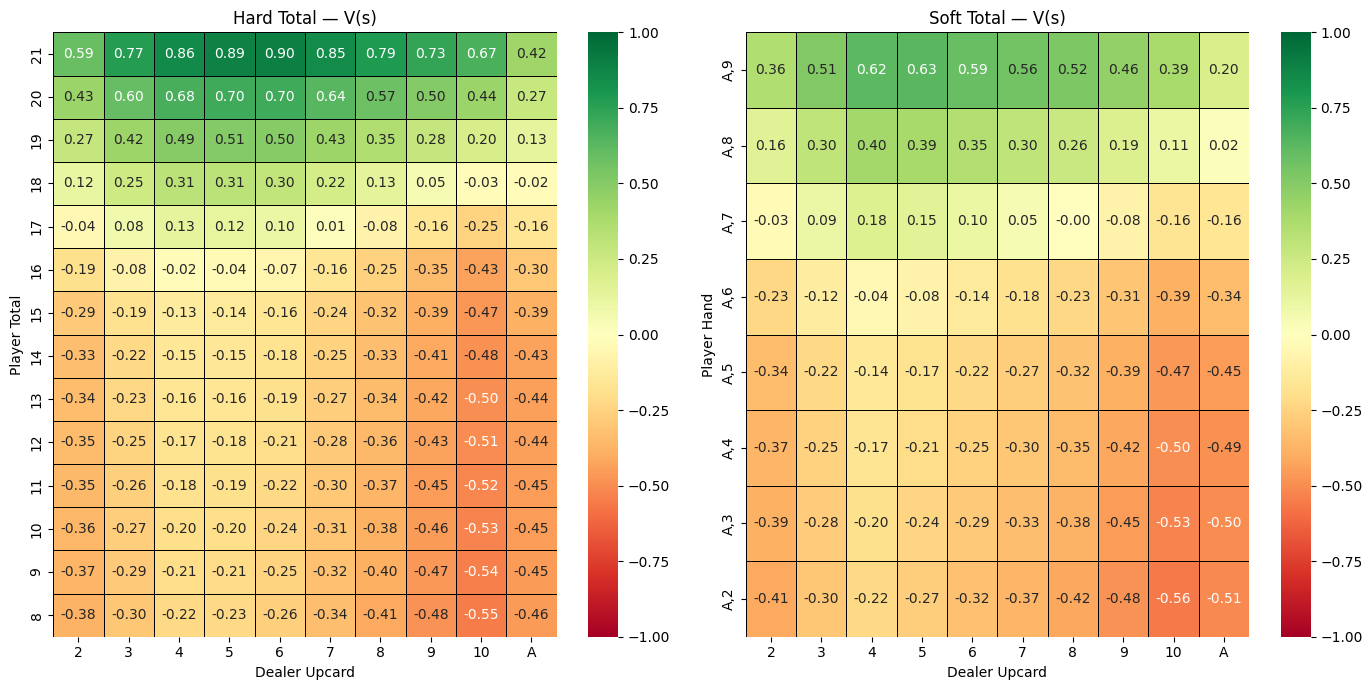

In [62]:
dealer_upcards = [(i, str(i)) for i in range(2, 11)] + [(1, 'A')]

def v_hat(player_sum, dealer_up, usable_ace):
    s1, s2, s3 = player_sum - 1, dealer_up - 1, usable_ace
    xi = torch.tensor(x(s1, s2, s3), dtype=torch.float32)
    with torch.no_grad():
        return model_v(xi).squeeze().item()

hard_table = []
soft_table = []

for player_sum in range(8, 22):
    for dealer_up, dealer_label in dealer_upcards:
        hard_table.append({
            'Player': player_sum,
            'Dealer': dealer_label,
            'Value': v_hat(player_sum, dealer_up, 0),
        })

for player_sum in range(13, 21):
    hand = f"A,{player_sum - 11}"
    for dealer_up, dealer_label in dealer_upcards:
        soft_table.append({
            'Player': hand,
            'Dealer': dealer_label,
            'Value': v_hat(player_sum, dealer_up, 1),
        })

col_order = [str(i) for i in range(2, 11)] + ['A']
soft_hand_order = [f"A,{i}" for i in range(9, 1, -1)]
hard_pivot = pd.DataFrame(hard_table).pivot(index='Player', columns='Dealer', values='Value')[col_order].sort_index(ascending=False)
soft_pivot = pd.DataFrame(soft_table).pivot(index='Player', columns='Dealer', values='Value')[col_order].reindex(soft_hand_order)

plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
sns.heatmap(hard_pivot, cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=.5, linecolor='black', annot=True, fmt='.2f')
plt.title('Hard Total — V(s)')
plt.xlabel('Dealer Upcard')
plt.ylabel('Player Total')

plt.subplot(1, 2, 2)
sns.heatmap(soft_pivot, cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=.5, linecolor='black', annot=True, fmt='.2f')
plt.title('Soft Total — V(s)')
plt.xlabel('Dealer Upcard')
plt.ylabel('Player Hand')

plt.tight_layout()
plt.show()

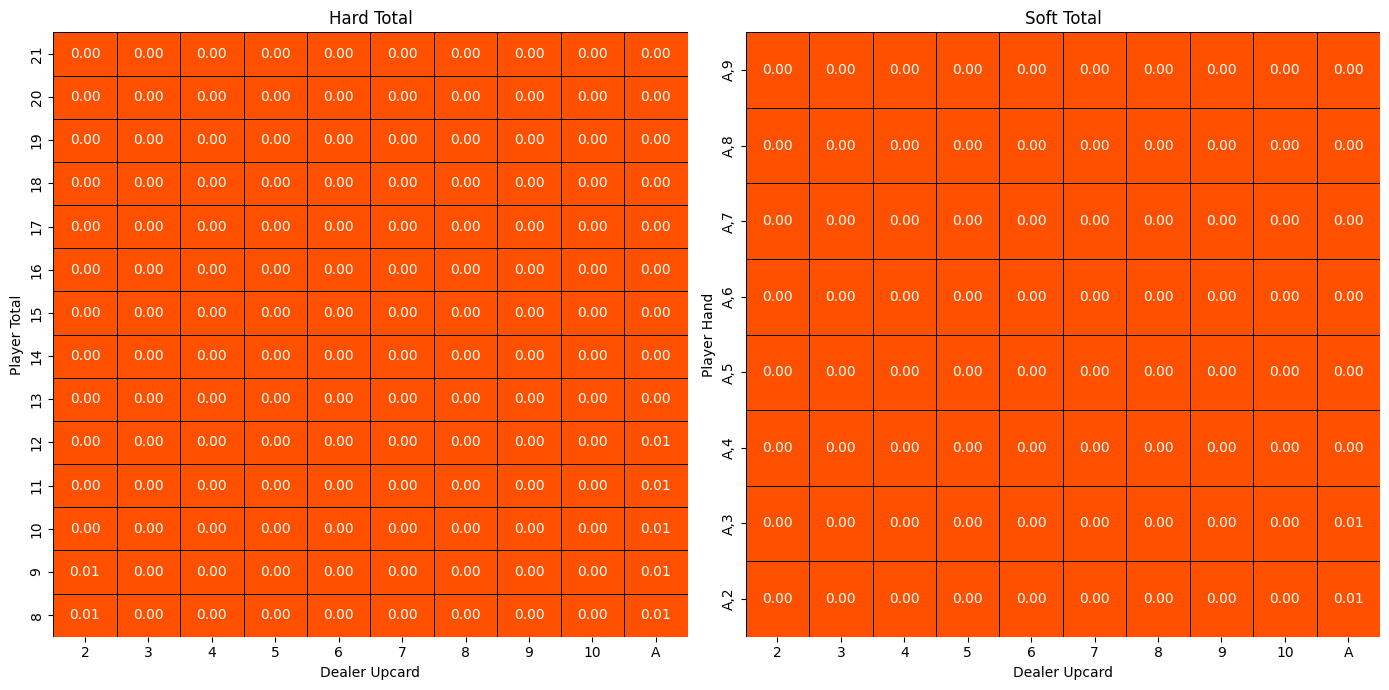

In [63]:

pink = '#FF5000' 
green = '#00C805' 
action_cmap = ListedColormap([pink, green])

def pi_hit(player_sum, dealer_up, usable_ace):
    s1, s2, s3 = player_sum - 1, dealer_up - 1, usable_ace
    xi = torch.tensor(x(s1, s2, s3), dtype=torch.float32)
    with torch.no_grad():
        return model_p(xi).squeeze().item()

dealer_upcards = [(i, str(i)) for i in range(2, 11)] + [(1, 'A')]

hard_table = []
soft_table = []
for player_sum in range(8, 22):
    pi = player_sum - 1
    for dealer_up, dealer_label in dealer_upcards:
        di = dealer_up - 1
        hard_table.append({
            'Player': player_sum,
            'Dealer': dealer_label,
            'P(hit)': pi_hit(player_sum, dealer_up, 0),
        })

for player_sum in range(13, 21):
    pi = player_sum - 1
    hand = f"A,{player_sum - 11}"
    for dealer_up, dealer_label in dealer_upcards:
        di = dealer_up - 1
        soft_table.append({
            'Player': hand,
            'Dealer': dealer_label,
            'P(hit)': pi_hit(player_sum, dealer_up, 1),
        })

col_order = [str(i) for i in range(2, 11)] + ['A']
soft_hand_order = [f"A,{i}" for i in range(9, 1, -1)]
hard_pivot = pd.DataFrame(hard_table).pivot(index='Player', columns='Dealer', values='P(hit)')[col_order].sort_index(ascending=False)
soft_pivot = pd.DataFrame(soft_table).pivot(index='Player', columns='Dealer', values='P(hit)')[col_order].reindex(soft_hand_order)

hard_action = (hard_pivot > 0.5).astype(int)
soft_action = (soft_pivot > 0.5).astype(int)

plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
sns.heatmap(hard_action, cmap=action_cmap, cbar=False,
            linewidths=.5, linecolor='black', annot=hard_pivot, fmt='.2f')
plt.title('Hard Total')
plt.xlabel('Dealer Upcard')
plt.ylabel('Player Total')

plt.subplot(1, 2, 2)
sns.heatmap(soft_action, cmap=action_cmap, cbar=False,
            linewidths=.5, linecolor='black', annot=soft_pivot, fmt='.2f')
plt.title('Soft Total')
plt.xlabel('Dealer Upcard')
plt.ylabel('Player Hand')

plt.tight_layout()
plt.show()